# Thesis dataset figures

Create clean, publication-ready visuals for the dataset section. The image choices are deliberately manual: edit the short configuration cell below, then run the remaining cells. All displayed images are centre-cropped to a square without distortion.

The notebook saves high-resolution PNG and PDF copies in `outputs/thesis_figures/`. Use the PNG in Word/PowerPoint or the PDF in LaTeX.

In [47]:
from pathlib import Path
from math import ceil
import csv

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
from PIL import Image, ImageOps

# Works whether Jupyter is started from the project root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'thesis_figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_LABELS = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3609.csv'
QUERY_LABELS = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3610.csv'

# ---- EDIT ONLY THIS BLOCK TO CHOOSE IMAGES --------------------------------
# Paths may be absolute or relative to PROJECT_ROOT. Keep the desired order.
# TIP: Run the contact-sheet cell below to browse frames and copy a path.
REPRESENTATIVE_IMAGES = [
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000065.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000419.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000482.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000561.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000725.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_000809.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_003970.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001112.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001164.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001404.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001190.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001428.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001571.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001612.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_003184.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002330.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001747.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002056.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002110.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001244.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002640.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002913.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_001986.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_002946.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_003605.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_003123.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_003245.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_004165.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_004207.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_004721.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_005661.jpg'),
    ('\n', 'datasets/dataset-2/frames-IMG_3609/frame_006904.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_007830.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008097.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008013.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008127.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008197.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008736.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008555.jpg'),
    ('', 'datasets/dataset-2/frames-IMG_3609/frame_008675.jpg'),
]

# One physical place in the two separate traversals.
SAME_LOCATION_PAIR = {
    'reference':  'datasets/dataset-2/frames-IMG_3609/frame_000100.jpg',
    'query': 'datasets/dataset-2/frames-IMG_3610/frame_000100.jpg',
    'location': 'Same physical location',
}

# Optional: two different places that look deceptively alike. Set both paths to enable.
AMBIGUITY_PAIR = {
    'left': 'datasets/dataset-2/frames-IMG_3609/frame_000100.jpg',
    'right':'datasets/dataset-2/frames-IMG_3609/frame_000150.jpg',
    'left_caption': 'Staircase — floor 1',
    'right_caption': 'Staircase — floor 2',
    'title': 'Perceptual ambiguity across floors',
}

# Editorial styling: quiet paper background, ink typography, and one teal accent.
DPI = 400
PAPER = '#F4F6F5'
CARD = '#FFFFFF'
INK = '#12212E'
MUTED = '#61717C'
BORDER = '#D9E1E4'
ACCENT = '#177E89'
WARM_ACCENT = '#D99A34'
TEXT = INK
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'text.color': INK})


In [33]:
def project_path(path):
    path = Path(path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def square_image(path):
    """Open, orientation-correct, and centre-crop an image to a square."""
    path = project_path(path)
    if not path.is_file():
        raise FileNotFoundError(f'Image not found: {path}')
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert('RGB')
        side = min(image.size)
        left = (image.width - side) // 2
        top = (image.height - side) // 2
        return image.crop((left, top, left + side, top + side))


def save_figure(fig, stem):
    for suffix in ('.png', '.pdf'):
        fig.savefig(OUTPUT_DIR / f'{stem}{suffix}', dpi=DPI, bbox_inches='tight',
                    facecolor=PAPER, pad_inches=0.06)
    print(f'Saved: {OUTPUT_DIR / stem}.png and .pdf')


def add_figure_heading(fig, eyebrow, title, subtitle=None):
    fig.text(0.5, 0.965, eyebrow.upper(), ha='center', va='top', fontsize=8.5,
             fontweight='bold', color=ACCENT)
    fig.text(0.5, 0.925, title, ha='center', va='top', fontsize=18,
             fontweight='bold', color=INK)
    if subtitle:
        fig.text(0.5, 0.882, subtitle, ha='center', va='top', fontsize=10.5, color=MUTED)


def draw_image(ax, path, caption, tag=None, tag_color=ACCENT):
    ax.imshow(square_image(path), interpolation='lanczos')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.15)
        spine.set_edgecolor(BORDER)
    if tag:
        ax.text(0.045, 0.94, tag, transform=ax.transAxes, va='top', ha='left',
                fontsize=8, fontweight='bold', color='white',
                bbox={'boxstyle': 'round,pad=0.42', 'facecolor': tag_color, 'edgecolor': 'none'})
    ax.text(0.5, -0.075, caption, transform=ax.transAxes, ha='center', va='top',
            fontsize=10.5, fontweight='semibold', color=INK, linespacing=1.15)


## Optional image browser

Set a label and traversal to preview evenly spaced candidate frames. The paths printed beneath the contact sheet can be pasted into the configuration cell.

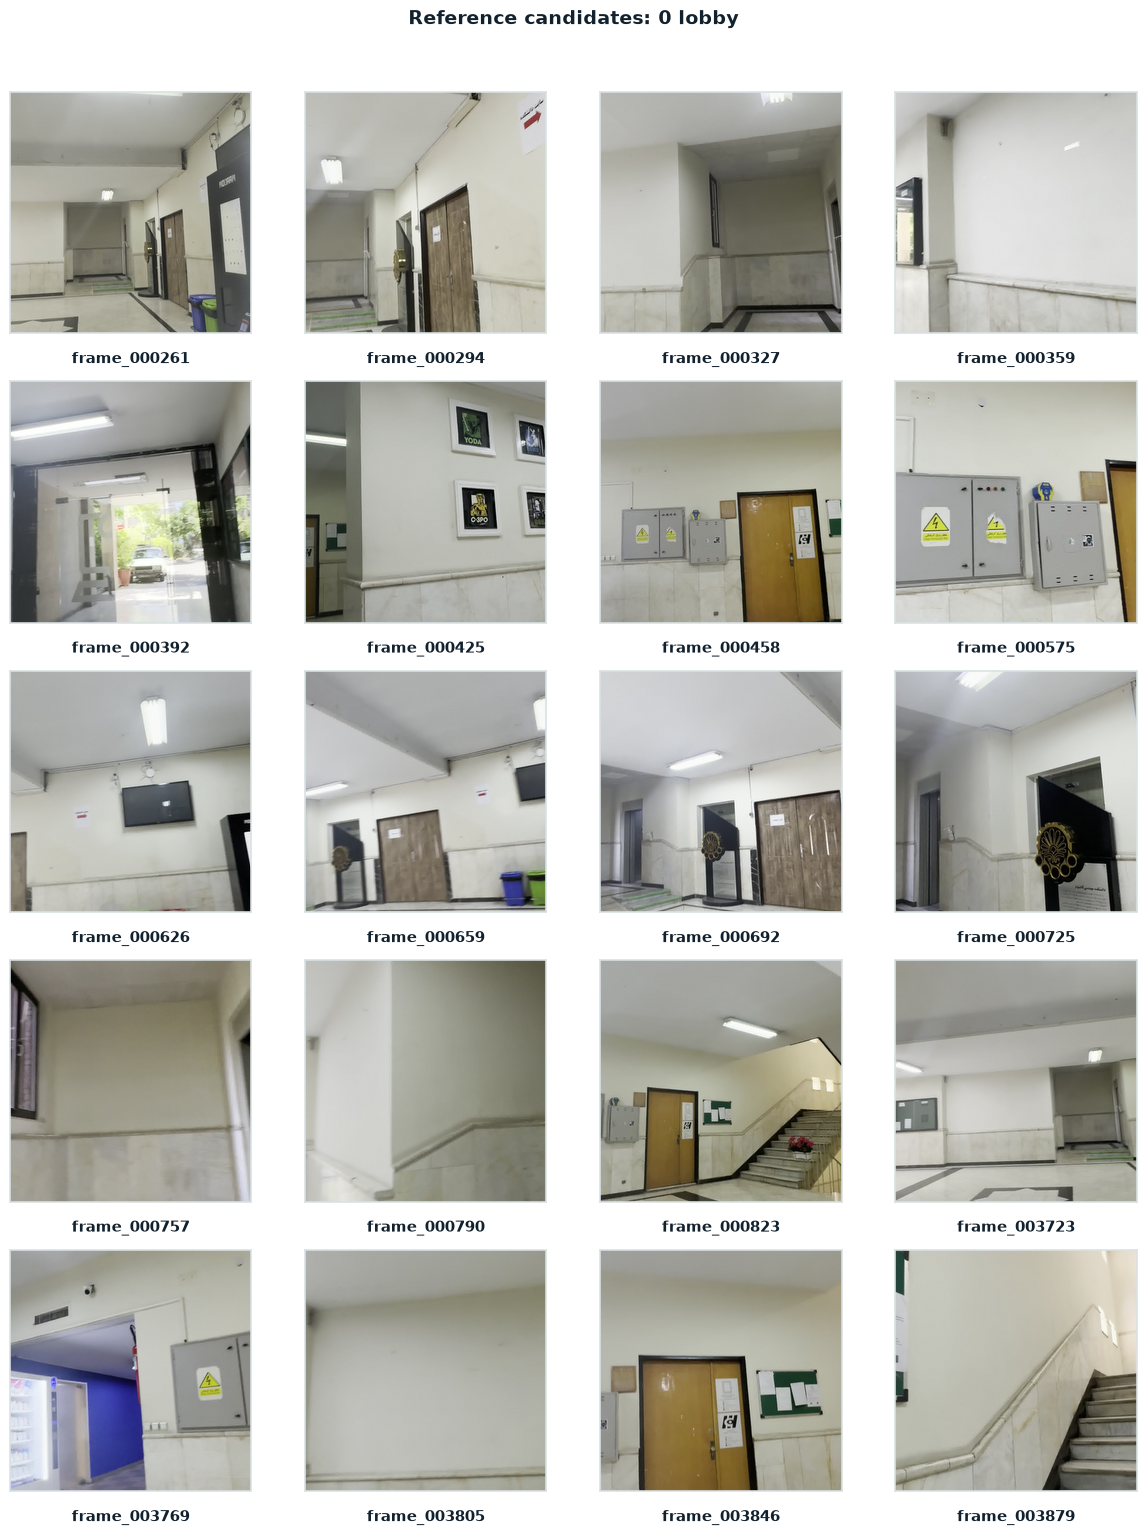

datasets/dataset-2/frames-IMG_3609/frame_000261.jpg
datasets/dataset-2/frames-IMG_3609/frame_000294.jpg
datasets/dataset-2/frames-IMG_3609/frame_000327.jpg
datasets/dataset-2/frames-IMG_3609/frame_000359.jpg
datasets/dataset-2/frames-IMG_3609/frame_000392.jpg
datasets/dataset-2/frames-IMG_3609/frame_000425.jpg
datasets/dataset-2/frames-IMG_3609/frame_000458.jpg
datasets/dataset-2/frames-IMG_3609/frame_000575.jpg
datasets/dataset-2/frames-IMG_3609/frame_000626.jpg
datasets/dataset-2/frames-IMG_3609/frame_000659.jpg
datasets/dataset-2/frames-IMG_3609/frame_000692.jpg
datasets/dataset-2/frames-IMG_3609/frame_000725.jpg
datasets/dataset-2/frames-IMG_3609/frame_000757.jpg
datasets/dataset-2/frames-IMG_3609/frame_000790.jpg
datasets/dataset-2/frames-IMG_3609/frame_000823.jpg
datasets/dataset-2/frames-IMG_3609/frame_003723.jpg
datasets/dataset-2/frames-IMG_3609/frame_003769.jpg
datasets/dataset-2/frames-IMG_3609/frame_003805.jpg
datasets/dataset-2/frames-IMG_3609/frame_003846.jpg
datasets/dat

In [25]:
BROWSE_LABEL = '0 lobby'  # Exact label, e.g. '1 stairs' or '2 elevator area'
BROWSE_TRAVERSAL = 'reference'  # 'reference' (IMG_3609) or 'query' (IMG_3610)
BROWSE_COUNT = 20

def labelled_paths(csv_path, wanted_label):
    with csv_path.open(newline='', encoding='utf-8') as handle:
        return [row['image_path'] for row in csv.DictReader(handle)
                if row['label'].strip() == wanted_label]

csv_path = REFERENCE_LABELS if BROWSE_TRAVERSAL == 'reference' else QUERY_LABELS
candidates = labelled_paths(csv_path, BROWSE_LABEL)
if not candidates:
    raise ValueError(f'No images found for label: {BROWSE_LABEL!r}')
indices = [round(i * (len(candidates) - 1) / (min(BROWSE_COUNT, len(candidates)) - 1))
           for i in range(min(BROWSE_COUNT, len(candidates)))] if len(candidates) > 1 else [0]
selected = [candidates[i] for i in indices]
fig, axes = plt.subplots(ceil(len(selected) / 4), 4, figsize=(12, 3 * ceil(len(selected) / 4)))
for ax, path in zip(axes.flat, selected):
    draw_image(ax, path, Path(path).stem)
for ax in axes.flat[len(selected):]:
    ax.set_axis_off()
fig.suptitle(f'{BROWSE_TRAVERSAL.title()} candidates: {BROWSE_LABEL}', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()
print('\n'.join(selected))


## Figure 1 — Representative scenes

The grid adapts to however many entries you add. For the requested five categories, it uses a compact 3+2 layout.

Saved: /Users/armin/Documents/indoor-VPR/outputs/thesis_figures/dataset_representative_scenes.png and .pdf


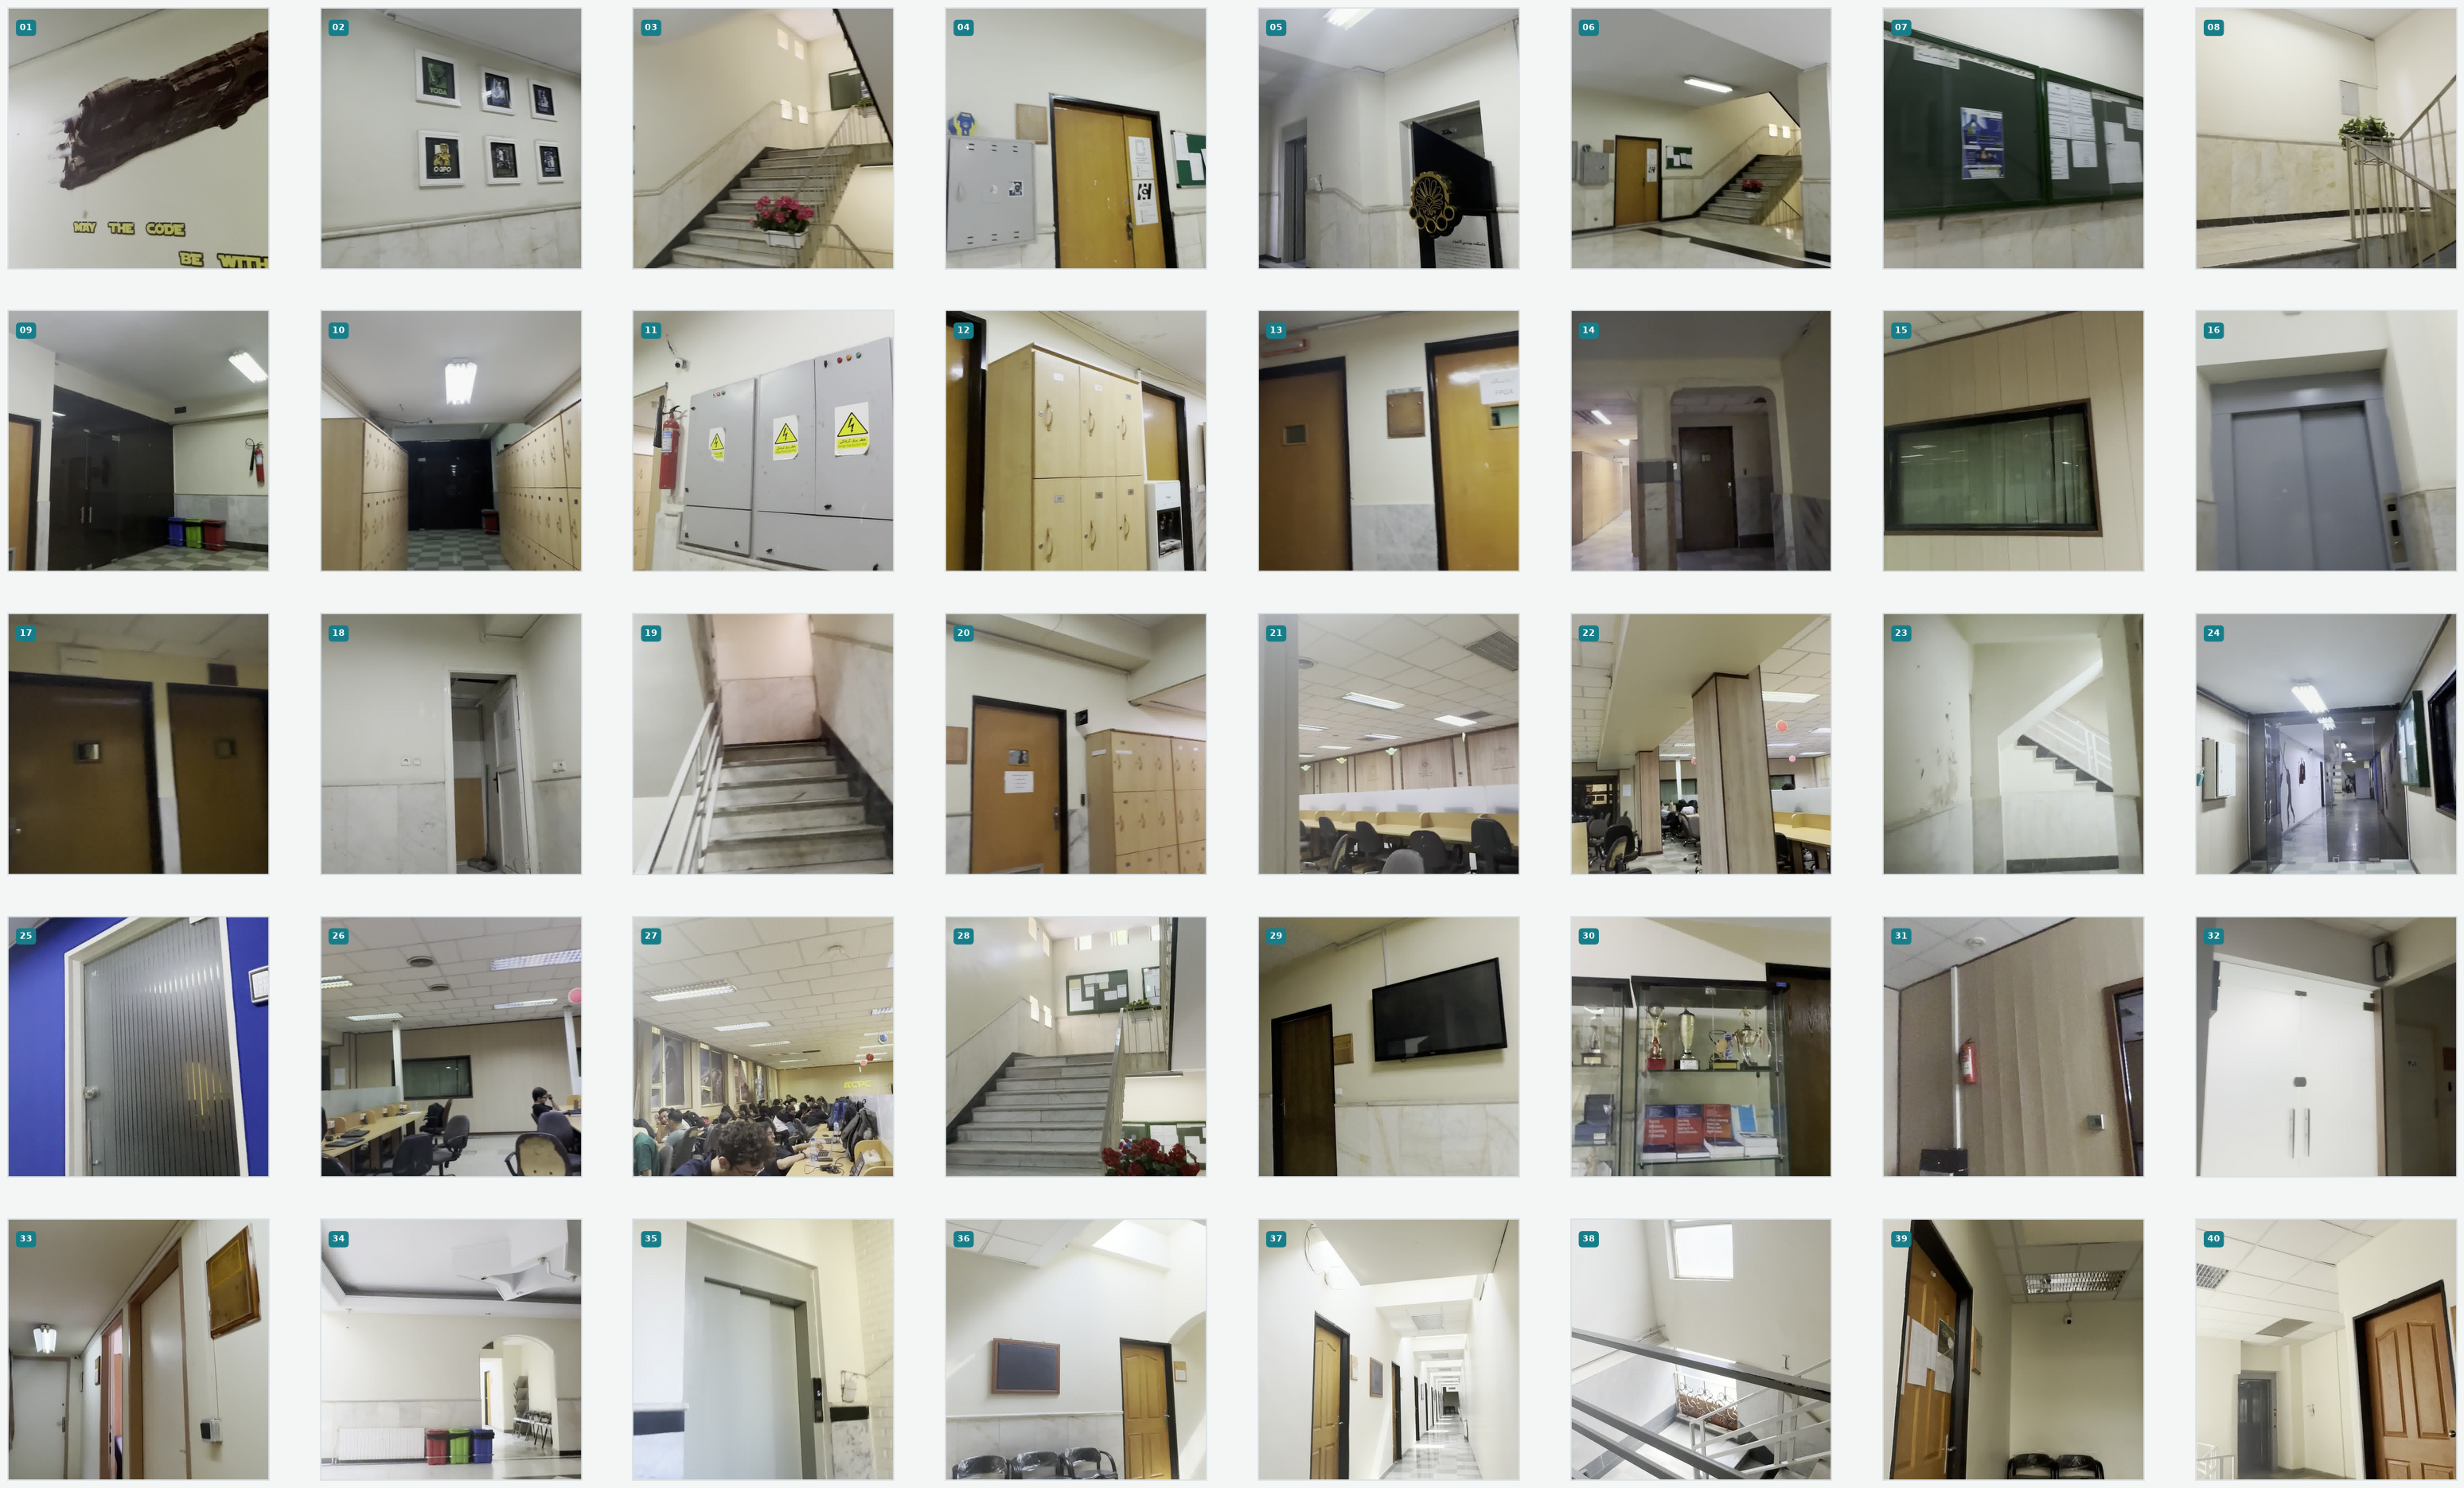

In [48]:
if not REPRESENTATIVE_IMAGES:
    print('Add image paths to REPRESENTATIVE_IMAGES, then rerun this cell.')
else:
    columns = min(8, len(REPRESENTATIVE_IMAGES))
    rows = ceil(len(REPRESENTATIVE_IMAGES) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4.15 * columns, 4.65 * rows), facecolor=PAPER)
    # add_figure_heading(fig, 'Indoor VPR dataset', 'A vocabulary of indoor places',
    #                    'Representative scenes from the reference traversal')
    axes = [axes] if len(REPRESENTATIVE_IMAGES) == 1 else axes.flat
    for number, (caption, path) in enumerate(REPRESENTATIVE_IMAGES, start=1):
        draw_image(axes[number - 1], path, caption, tag=f'{number:02d}')
    for ax in list(axes)[len(REPRESENTATIVE_IMAGES):]:
        ax.set_axis_off()
    fig.tight_layout(rect=(0.025, 0.03, 0.975, 0.84), h_pad=2.2, w_pad=1.35)
    save_figure(fig, 'dataset_representative_scenes')
    plt.show()


## Figure 2 — Reference–query correspondence

A matched-location pair makes cross-traversal visual place recognition concrete. The arrow is a visual cue only; it does not imply image alignment.

Saved: /Users/armin/Documents/indoor-VPR/outputs/thesis_figures/dataset_same_location_reference_query.png and .pdf


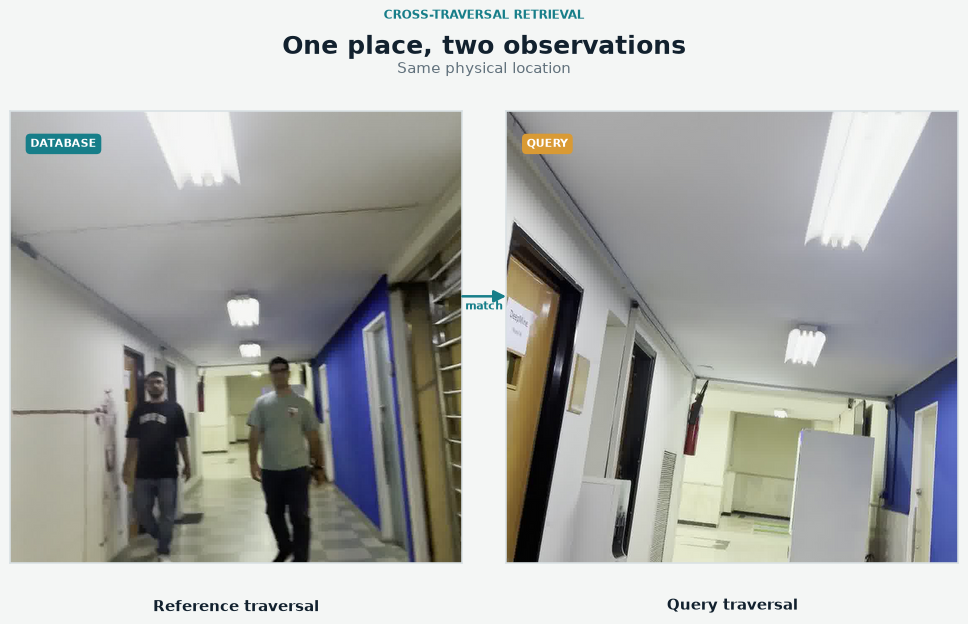

In [27]:
if not (SAME_LOCATION_PAIR['reference'] and SAME_LOCATION_PAIR['query']):
    print('Set SAME_LOCATION_PAIR reference and query paths to create this figure.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10.7, 6.3), facecolor=PAPER)
    add_figure_heading(fig, 'Cross-traversal retrieval', 'One place, two observations',
                       SAME_LOCATION_PAIR['location'])
    draw_image(axes[0], SAME_LOCATION_PAIR['reference'], 'Reference traversal', tag='DATABASE')
    draw_image(axes[1], SAME_LOCATION_PAIR['query'], 'Query traversal', tag='QUERY', tag_color=WARM_ACCENT)
    fig.add_artist(FancyArrowPatch((0.477, 0.51), (0.523, 0.51), transform=fig.transFigure,
                                   arrowstyle='-|>', mutation_scale=18, linewidth=1.8, color=ACCENT))
    fig.text(0.5, 0.485, 'match', ha='center', va='bottom', fontsize=8,
             fontweight='bold', color=ACCENT)
    fig.tight_layout(rect=(0.04, 0.06, 0.96, 0.83), w_pad=2.7)
    save_figure(fig, 'dataset_same_location_reference_query')
    plt.show()


## Optional Figure 3 — Perceptual ambiguity

Use this for two *different* locations—such as similar staircases or corridors on separate floors—that can confuse appearance-based retrieval.

Saved: /Users/armin/Documents/indoor-VPR/outputs/thesis_figures/dataset_perceptual_ambiguity.png and .pdf


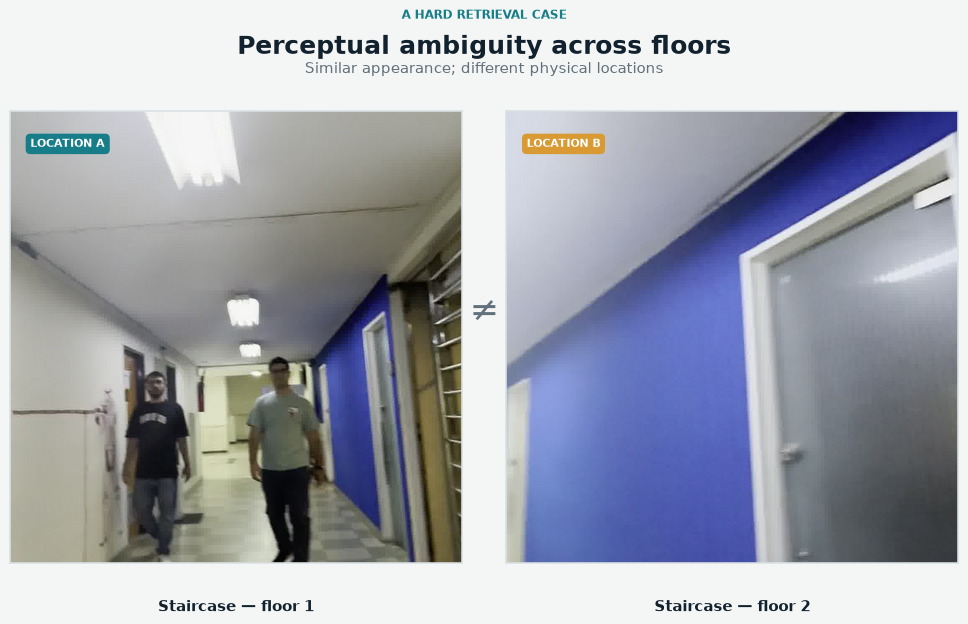

In [28]:
if not (AMBIGUITY_PAIR['left'] and AMBIGUITY_PAIR['right']):
    print('Set AMBIGUITY_PAIR left and right paths to create this optional figure.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10.7, 6.3), facecolor=PAPER)
    add_figure_heading(fig, 'A hard retrieval case', AMBIGUITY_PAIR['title'],
                       'Similar appearance; different physical locations')
    draw_image(axes[0], AMBIGUITY_PAIR['left'], AMBIGUITY_PAIR['left_caption'], tag='LOCATION A')
    draw_image(axes[1], AMBIGUITY_PAIR['right'], AMBIGUITY_PAIR['right_caption'],
               tag='LOCATION B', tag_color=WARM_ACCENT)
    fig.text(0.5, 0.485, '≠', ha='center', va='center', fontsize=25, fontweight='light', color=MUTED)
    fig.tight_layout(rect=(0.04, 0.06, 0.96, 0.83), w_pad=2.7)
    save_figure(fig, 'dataset_perceptual_ambiguity')
    plt.show()


## Suggested thesis captions

**Representative scenes.** Examples of the indoor environments represented in the dataset, including corridors, lobbies, staircases, elevator areas, and repeated visual structure across floors. Images are shown as square centre crops for consistent presentation.

**Cross-traversal correspondence.** Reference and query frames depicting the same physical location during separate traversals. Changes in viewpoint, illumination, and transient scene content motivate the visual place recognition task.

**Perceptual ambiguity.** Two distinct locations with similar visual appearance. Such repeated indoor structure can cause a global-descriptor retrieval system to return an incorrect place, particularly across floors.